# Exercises XP: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts to support intuition and transfer to other AI topics.



## Reference from the exercise

**What you will learn**  
- The differences between traditional machine learning and deep learning.
- The structure and working of artificial neural networks. How to generate, visualize, and analyze datasets with noise.
- Techniques for fitting polynomial regression models and understanding overfitting.
- The importance of cross-validation in model selection.

**What you will create**  
- A comparative table of traditional machine learning vs deep learning.
- A simple ANN diagram with labeled components.
- A noisy dataset visualized with a scatter plot.
- Polynomial regression models of varying degrees.
- A cross-validation analysis to select an optimal polynomial degree.


## 🌟 Exercise 1: Deep Learning vs Traditional Machine Learning

**As stated in the exercise**  
Objective. Understand the differences between traditional machine learning and deep learning.  
Instructions. Create a table comparing Feature Engineering, Data Processing, Scalability, Pattern Discovery, and Computational Requirements. Identify one real world problem where traditional ML is better, and one where deep learning is better. Write a short paragraph explaining why deep learning has an advantage in unstructured data processing.

**Guidance**  
Use a markdown table for the comparison, keep wording concise and concrete, then write two short examples and one paragraph in full sentences.

**To-Do:** Complete the comparison table below by filling in each cell with your own wording.


| Aspect                         | Traditional ML                                                    | Deep Learning                                        |
| ------------------------------ | ----------------------------------------------------------------- | ---------------------------------------------------- |
| **Feature Engineering**        | Manual: features are designed by humans based on domain knowledge | Automatic: model learns features from raw data       |
| **Data Processing**            | Structured, clean data                                   | Unstructured data (images, text, audio) |
| **Scalability**                | Small–medium datasets                               | Large datasets and more data           |
| **Pattern Discovery**          | Finds simple patterns                                             | Learns complex, hierarchical patterns                |
| **Computational Requirements** | Low (CPU)                                | High (GPUs, TPUs)                      |


**To-Do:**

**Traditional ML:**
Predicting house prices using features like size, location, and number of rooms.
Traditional ML works better here because the data is structured and relationships are relatively simple.

**Deep Learning:**
Image recognition (e.g., detecting objects in photos).
Deep learning is better because it can automatically extract complex visual features from raw pixel data.


**To-Do:**

Deep learning has a strong advantage in unstructured data processing because it uses representation learning to automatically extract meaningful features from raw data. Instead of relying on manually designed inputs, neural networks learn hierarchical features, where simple patterns (like edges in images) are combined into more complex structures (like objects). This makes deep learning especially powerful for tasks such as image, speech and text processing.

## 🌟 Exercise 2: Artificial Neural Networks (ANNs)

**As stated in the exercise**  
Objective. Identify and understand the key components of an ANN.  
Instructions. Draw or use a diagram tool to create an ANN with an input layer of 3 neurons, one hidden layer of 4 neurons, and an output layer of 2 neurons. Label neurons, weights, biases, activation function, and layers. Write a short description of how information flows through the network.

**Guidance**  
A clear schematic is preferred. Ensure every requested label appears exactly once and is readable.



**To-Do:** Provide a 3–5 sentence description of forward propagation in your diagram. Refer explicitly to inputs, weighted sums, biases, activation, and outputs.
Forward Propagation Description:

During forward propagation, the input values (X1, X2, X3) are fed into the network and multiplied by weights. Each neuron computes a weighted sum of its inputs and adds a bias term. This result is then passed through an activation function, such as ReLU, to introduce nonlinearity. The activated outputs from the hidden layer are passed to the output layer, where the same process is repeated. Finally, the network produces the output values (Y1, Y2).

**Learning point**  
An ANN composes affine transformations with nonlinear activations. The affine part mixes features through weights and biases. The nonlinearity enables modeling of complex decision boundaries.


## 🌟 Exercise 3: Creating the Dataset and Visualizing the Data

**As stated in the exercise**  
Objective. Generate a dataset with noise and visualize it.  
Instructions. Import numpy, matplotlib.pyplot, and mean_squared_error from sklearn.metrics. Create 20 points using \(y = -x^2\) with Gaussian noise \(\mathcal{N}(0, 0.05)\). Plot the points with a scatter plot. Split into a training set with the first 12 points and a test set with the last 8 points.


In [3]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)  # 20 points from -1 to <1 step 0.1
print("x shape:", x.shape)

x shape: (20,)


In [4]:
# To-Do: generate y with noise using np.random.normal()
y = -x**2 + np.random.normal(0, 0.05, size=x.shape)
print("y shape:", y.shape)

y shape: (20,)


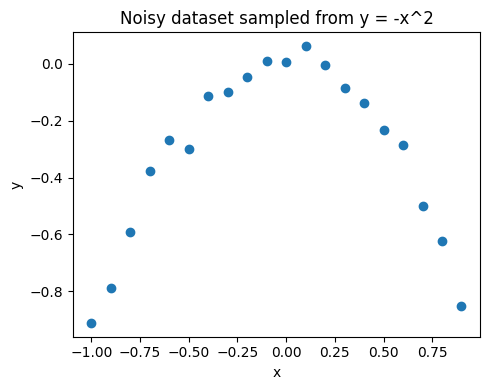

In [5]:
# PREFILLED: just execute (scatter plot of the dataset)
plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.title("Noisy dataset sampled from y = -x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [6]:
# To-Do: split into train (first 12 points) and test (last 8 points)
x_train, y_train = x[:12], y[:12]
x_test, y_test = x[12:], y[12:]
print("train sizes:", x_train.shape, y_train.shape, "test sizes:", x_test.shape, y_test.shape)

train sizes: (12,) (12,) test sizes: (8,) (8,)


**Learning point**  
Visualizing noisy data helps separate signal from noise. Splitting into train and test allows you to detect when a model overfits noise instead of learning the underlying pattern.


## 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

**As stated in the exercise**  
Objective: Fit polynomial models of varying degrees and observe overfitting.  

Instructions: Define `polynomial_fit(degree)` that returns the fitted polynomial coefficients from training data. Define `plot_polyfit(degree)` that draws the training set, the test set, and the fitted polynomial curve. Visualize fits for degrees 1, 7, and 11. Observe behavior on training and test sets as degree increases.


In [7]:
# To-Do: implement polynomial_fit
# Hints: use np.polyfit() to get coefficients, and np.poly1d for a callable polynomial
def polynomial_fit(degree: int):
    coeffs = np.polyfit(x_train, y_train, degree)
    return np.poly1d(coeffs)


In [8]:
# To-Do: implement plot_polyfit
# import numpy as np
# import matplotlib.pyplot as plt
def plot_polyfit(degree: int):
    # 1) fit
    poly = polynomial_fit(degree)

    # 2) create a dense linspace over x range
    x_dense = np.linspace(x.min(), x.max(), 300)

    # 3) evaluate fitted polynomial
    y_dense = poly(x_dense)

    # 4) scatter train and test, and plot curve
    plt.figure(figsize=(6, 4))
    plt.scatter(x_train, y_train, label="Train set")
    plt.scatter(x_test, y_test, label="Test set")
    plt.plot(x_dense, y_dense, label=f"Degree {degree} fit")

    # 5) display
    plt.title(f"Polynomial Fit (degree={degree})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.tight_layout()
    plt.show()


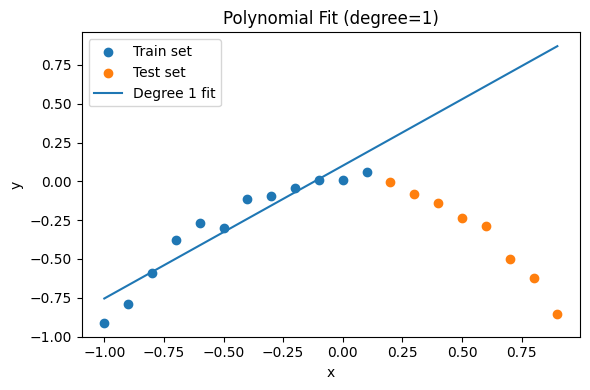

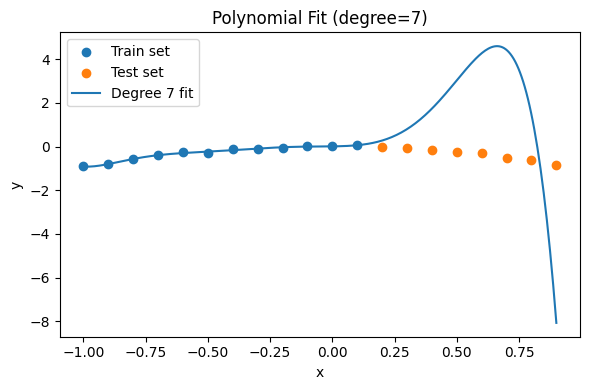

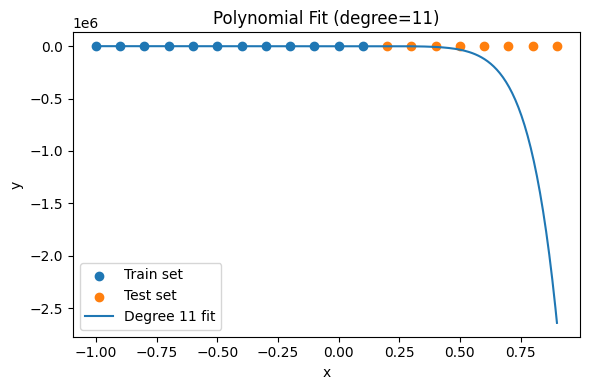

In [9]:
# To-Do: visualize degrees 1, 7, and 11
plot_polyfit(1)
plot_polyfit(7)
plot_polyfit(11)

**Learning point**  
Higher degree polynomials can perfectly fit training data yet fail to generalize. This is overfitting. You should always check test error, not just training error.

![image.png](https://github.com/user-attachments/assets/cdfb495c-066a-4efb-a361-f4b9d4ade35c)

## 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree

**As stated in the exercise**  
Objective: Use cross-validation to determine the best polynomial degree.  

Instructions: Loop degrees from 1 to 11. For each degree, compute the RMSE on the training and test sets. Store results in a list. Plot RMSE vs degree with a logarithmic y axis. Identify the degree minimizing test RMSE and confirm it matches the true model \(y=-x^2\).


In [13]:
# To-Do: compute RMSE per degree for train and test
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

degrees = range(1, 12)
rows = []

for d in degrees:
    coeffs = np.polyfit(x_train, y_train, d)
    poly = np.poly1d(coeffs)

    y_train_pred = poly(x_train)
    y_test_pred = poly(x_test)

    rmse_train = rmse(y_train, y_train_pred)
    rmse_test = rmse(y_test, y_test_pred)

    rows.append((d, rmse_train, rmse_test))

rows[:3]

[(1, np.float64(0.1002263344864799), np.float64(1.0240708833556866)),
 (2, np.float64(0.04114590494650985), np.float64(0.12578064282386534)),
 (3, np.float64(0.037336922311085964), np.float64(0.769651993080075))]

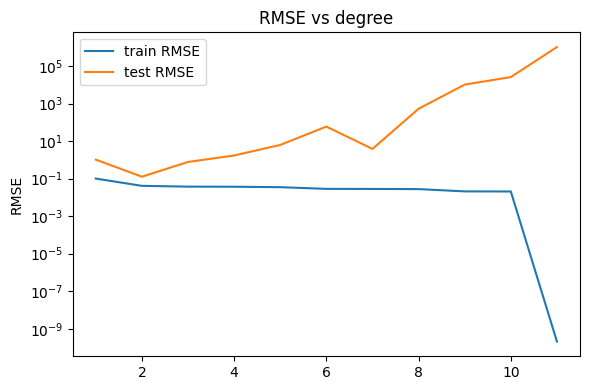

In [14]:
# Pre-filled: plotting RMSE curves (one figure, two curves)
degs = [r[0] for r in rows]
rmse_tr = [r[1] for r in rows]
rmse_te = [r[2] for r in rows]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(degs, rmse_tr, label="train RMSE")
plt.plot(degs, rmse_te, label="test RMSE")

plt.yscale("log")
plt.ylabel("RMSE")
plt.title("RMSE vs degree")
plt.legend()
plt.tight_layout()
plt.show()

**To-Do:** The best polynomial degree is 2 because it gives the lowest test RMSE. This fits the true function (y = −x^2), which is a curve. Lower degrees are too simple and miss the pattern, while higher degrees are too complex and fit the noise.